<a href="https://colab.research.google.com/github/nekosrei/volos-transport-hub-accessibility/blob/main/volos_transport_hub_accessibility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install osmnx -q

Κόμβοι: 6702 | Δρόμοι: 19966


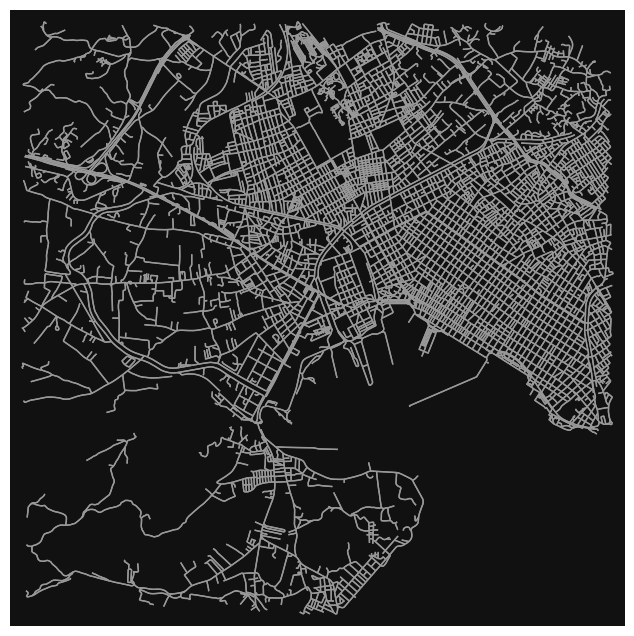

(<Figure size 800x800 with 1 Axes>,
 <Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>)

In [3]:
import osmnx as ox
import networkx as nx
import geopandas as gpd

G = ox.graph_from_address("Σέκερη, Βόλος, Ελλάδα", dist=3000, network_type="walk")
print("Κόμβοι:", len(G.nodes), "| Δρόμοι:", len(G.edges))
ox.plot_graph(G, node_size=0, figsize=(8, 8))

In [4]:
center = ox.geocode("Σέκερη, Βόλος, Ελλάδα")
print("Κέντρο αναζήτησης:", center)

tags = {
    "amenity": ["bus_station", "ferry_terminal", "bicycle_rental", "townhall"],
    "railway": ["station"],
    "tourism": ["information"],
    "public_transport": ["station"],
}
poi = ox.features_from_point(center, tags=tags, dist=1800)

# υπολογισμός κέντρου κάθε στοιχείου (σε μετρικό σύστημα, μετά πίσω σε lat/lon)
poi_m = poi.to_crs(2100)
cent = poi_m.geometry.centroid.to_crs(4326)
poi["lat"] = cent.y
poi["lon"] = cent.x

cols = [c for c in ["name", "amenity", "railway", "tourism", "public_transport", "lat", "lon"] if c in poi.columns]
print(poi[cols].reset_index(drop=True).to_string())

Κέντρο αναζήτησης: (39.360652, 22.9308222)
                                                              name           amenity  railway      tourism public_transport        lat        lon
0                                                  Παλιό Δημαρχείο          townhall      NaN          NaN              NaN  39.374768  22.932415
1                                                              NaN               NaN      NaN  information              NaN  39.359427  22.947430
2                                                       Volos Port    ferry_terminal      NaN          NaN          station  39.357198  22.943219
3                ΚΕΝ. ΑΦΕΤΗΡΙΑ Νο2, Νο4, Νο5, Νο7, Νο9, Νο11, Νο49       bus_station      NaN          NaN          station  39.361448  22.932569
4            ΚΤΕΛ - Σταθμός Υπεραστικών Λεωφορείων Νομού Μαγνησίας       bus_station      NaN          NaN          station  39.361116  22.933090
5                                        ΜΕΤΚΑ -Νο3 ΑΦΕΤΗΡΙΑ+ΤΕΡΜΑ       bus_stat

In [5]:
import math
import pandas as pd

points = {
    "Hub (Αστικό ΚΤΕΛ Βόλου)": (39.361582, 22.932514),
    "Υπεραστικό ΚΤΕΛ": (39.361059, 22.933128),
    "Σιδηροδρομικός σταθμός": (39.364235, 22.936900),
    "Επιβατική προβλήτα": (39.357198, 22.943219),
    "Κέντρο πληροφόρησης": (39.361707, 22.932885),
    "Δημαρχείο": (39.362676, 22.940965),
}
hub = "Hub (Αστικό ΚΤΕΛ Βόλου)"

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi, dlmb = p2 - p1, math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dlmb/2)**2
    return 2 * R * math.asin(math.sqrt(a))

nodes = {n: ox.distance.nearest_nodes(G, X=lon, Y=lat) for n, (lat, lon) in points.items()}
SPEED = 75   # μέτρα ανά λεπτό (4,5 χλμ/ώρα), όπως στην πτυχιακή: 900 μ. ≈ 12 λεπτά

rows = []
for name, (lat, lon) in points.items():
    if name == hub:
        continue
    walk = nx.shortest_path_length(G, nodes[hub], nodes[name], weight="length")
    straight = haversine(*points[hub], lat, lon)
    rows.append({
        "Προορισμός": name,
        "Ευθεία (μ.)": round(straight),
        "Πεζή στο δίκτυο (μ.)": round(walk),
        "Χρόνος (λεπτά)": round(walk / SPEED, 1),
        "Εντός 500 μ.": walk <= 500,
    })

results = pd.DataFrame(rows)
print(results.to_string(index=False))

            Προορισμός  Ευθεία (μ.)  Πεζή στο δίκτυο (μ.)  Χρόνος (λεπτά)  Εντός 500 μ.
       Υπεραστικό ΚΤΕΛ           79                    61             0.8          True
Σιδηροδρομικός σταθμός          479                   820            10.9         False
    Επιβατική προβλήτα         1041                  1554            20.7         False
   Κέντρο πληροφόρησης           35                    43             0.6          True
             Δημαρχείο          737                   845            11.3         False


Hub (Αστικό ΚΤΕΛ Βόλου) -> 19 μ. από τον κόμβο του δικτύου
Υπεραστικό ΚΤΕΛ -> 38 μ. από τον κόμβο του δικτύου
Σιδηροδρομικός σταθμός -> 28 μ. από τον κόμβο του δικτύου
Επιβατική προβλήτα -> 0 μ. από τον κόμβο του δικτύου
Κέντρο πληροφόρησης -> 22 μ. από τον κόμβο του δικτύου
Δημαρχείο -> 32 μ. από τον κόμβο του δικτύου


(39.352, 39.368)

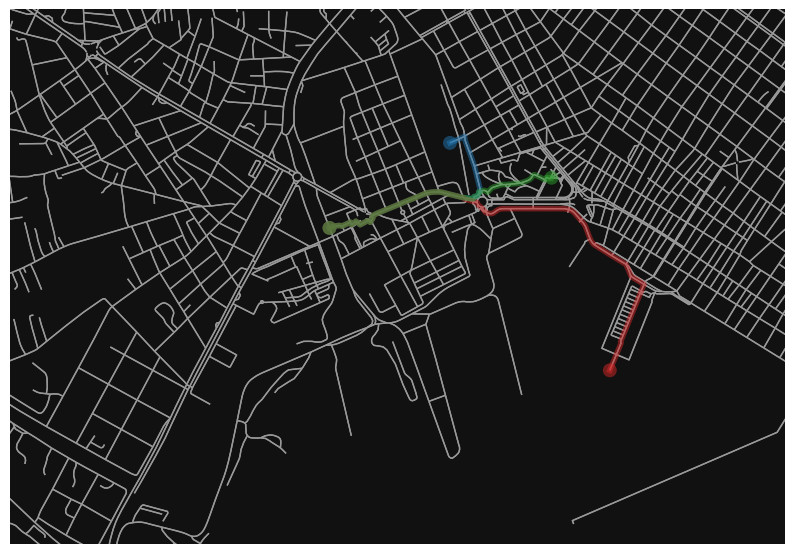

In [6]:
# 1) πόσο «μετακινήθηκε» κάθε σημείο όταν κόλλησε στο δίκτυο
for n, (lat, lon) in points.items():
    nid = nodes[n]
    d = haversine(lat, lon, G.nodes[nid]["y"], G.nodes[nid]["x"])
    print(n, "->", round(d), "μ. από τον κόμβο του δικτύου")

# 2) οι διαδρομές πάνω στο χάρτη
targets = ["Σιδηροδρομικός σταθμός", "Επιβατική προβλήτα", "Δημαρχείο"]
routes = [ox.shortest_path(G, nodes[hub], nodes[t], weight="length") for t in targets]
fig, ax = ox.plot_graph_routes(
    G, routes, route_colors=["tab:blue", "tab:red", "tab:green"],
    route_linewidth=4, node_size=0, figsize=(10, 10), show=False, close=False
)
ax.set_xlim(22.92, 22.95)
ax.set_ylim(39.352, 39.368)

Κόμβοι δικτύου εντός 500 μ.: 213


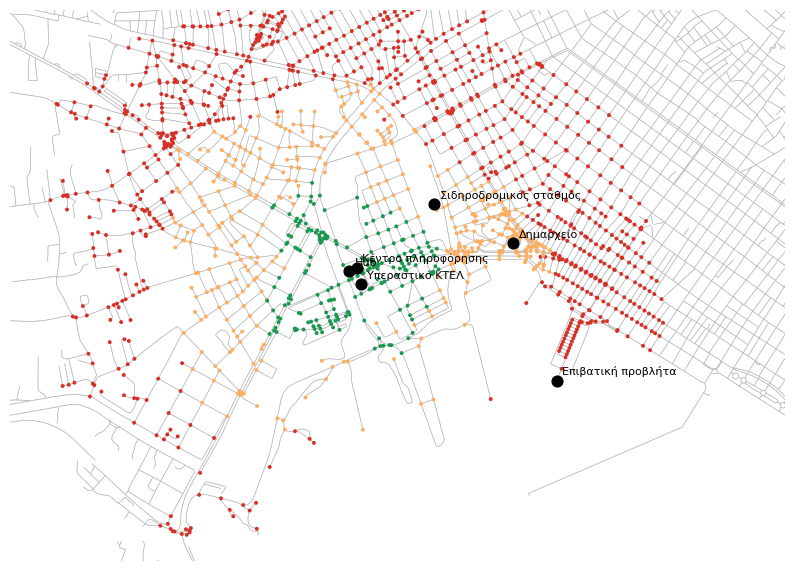

In [7]:
import matplotlib.pyplot as plt

hub_node = nodes[hub]
dist = nx.single_source_dijkstra_path_length(G, hub_node, weight="length", cutoff=1600)

def color(d):
    if d <= 500:  return "#1a9850"   # πράσινο: εντός 500 μ.
    if d <= 1000: return "#fdae61"   # πορτοκαλί: 500-1000 μ.
    return "#d73027"                 # κόκκινο: πάνω από 1000 μ.

node_colors = [color(dist[n]) if n in dist else "#cccccc" for n in G.nodes]
node_sizes  = [8 if n in dist else 0 for n in G.nodes]

fig, ax = ox.plot_graph(G, node_color=node_colors, node_size=node_sizes,
                        edge_color="#bbbbbb", edge_linewidth=0.4, bgcolor="white",
                        figsize=(10, 10), show=False, close=False)
ax.set_xlim(22.915, 22.955)
ax.set_ylim(39.350, 39.372)

for name, (lat, lon) in points.items():
    ax.scatter(lon, lat, s=60, c="black", zorder=5)
    ax.annotate(name.split(" (")[0], (lon, lat), fontsize=8,
                xytext=(4, 4), textcoords="offset points")

plt.savefig("accessibility_map.png", dpi=200, bbox_inches="tight")
print("Κόμβοι δικτύου εντός 500 μ.:", sum(1 for d in dist.values() if d <= 500))

Street length within 500 m of the hub: 13.4 km
Street length within 1000 m of the hub: 48.9 km


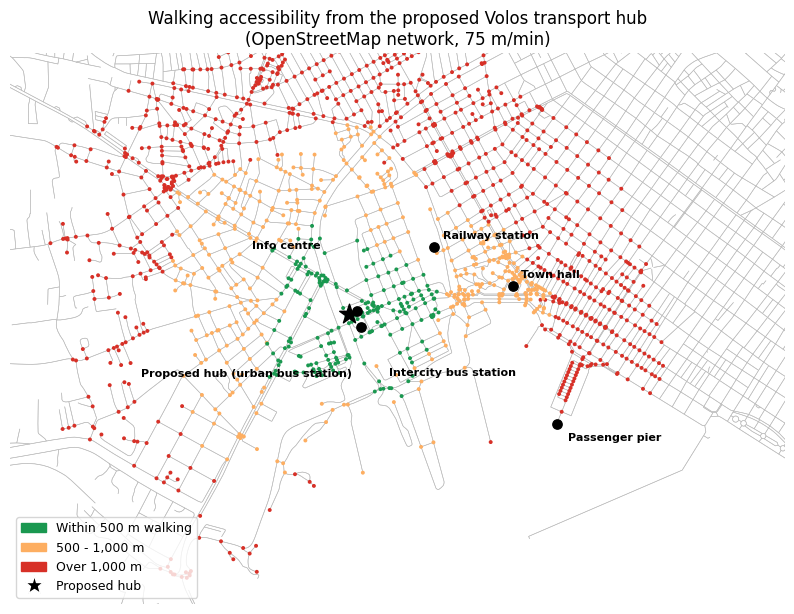

In [9]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --- 1) μήκος δρόμων εντός κάθε ζώνης (κάθε δρόμος μετράει μία φορά) ---
try:
    G_u = ox.convert.to_undirected(G)
except AttributeError:
    G_u = ox.utils_graph.get_undirected(G)

def street_km(threshold):
    total = 0
    for u, v, data in G_u.edges(data=True):
        if dist.get(u, 1e9) <= threshold and dist.get(v, 1e9) <= threshold:
            total += data["length"]
    return total / 1000

for t in (500, 1000):
    print(f"Street length within {t} m of the hub: {street_km(t):.1f} km")

# --- 2) αποθήκευση πίνακα αποτελεσμάτων ---
results.to_csv("walking_distances.csv", index=False)

# --- 3) καθαρός χάρτης στα αγγλικά ---
labels = {
    "Hub (Αστικό ΚΤΕΛ Βόλου)": "Proposed hub (urban bus station)",
    "Υπεραστικό ΚΤΕΛ": "Intercity bus station",
    "Σιδηροδρομικός σταθμός": "Railway station",
    "Επιβατική προβλήτα": "Passenger pier",
    "Κέντρο πληροφόρησης": "Info centre",
    "Δημαρχείο": "Town hall",
}
offsets = {
    "Hub (Αστικό ΚΤΕΛ Βόλου)": (-150, -45),
    "Υπεραστικό ΚΤΕΛ": (20, -35),
    "Κέντρο πληροφόρησης": (-75, 45),
    "Σιδηροδρομικός σταθμός": (6, 6),
    "Δημαρχείο": (6, 6),
    "Επιβατική προβλήτα": (8, -12),
}

fig, ax = ox.plot_graph(G, node_color=node_colors, node_size=node_sizes,
                        edge_color="#bbbbbb", edge_linewidth=0.4, bgcolor="white",
                        figsize=(10, 10), show=False, close=False)
ax.set_xlim(22.915, 22.955)
ax.set_ylim(39.350, 39.372)

for name, (lat, lon) in points.items():
    if name == hub:
        ax.scatter(lon, lat, s=220, c="black", marker="*", zorder=6)
    else:
        ax.scatter(lon, lat, s=45, c="black", zorder=5)
    ax.annotate(labels[name], (lon, lat), fontsize=8, fontweight="bold",
                xytext=offsets[name], textcoords="offset points")

legend = [
    Patch(color="#1a9850", label="Within 500 m walking"),
    Patch(color="#fdae61", label="500 - 1,000 m"),
    Patch(color="#d73027", label="Over 1,000 m"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="black", markersize=14, label="Proposed hub"),
]
ax.legend(handles=legend, loc="lower left", fontsize=9)
ax.set_title("Walking accessibility from the proposed Volos transport hub\n(OpenStreetMap network, 75 m/min)", fontsize=12)

plt.savefig("accessibility_map.png", dpi=200, bbox_inches="tight")
plt.show()